# Using Dicrete Cosine Transform to classify handwritten digits

Just a crazy Idea had. Basically seeing how frequency could be better moddeled using the DCT coordinate space which is also used for JPEG compression. Maybe by changing to a different coordinate system and then applying SVD to find the orthogonal eigenvectors of this new curve space might be better to preserve more of the curves of the tougher numbers???

BAD IDEA

I thought about it more but what ends up happening is that transforming to DCT then finding the eigenvectors I get the same eigenvectors in DCT basis. So we end up finding eigenvectors in DCT space that represent the same variance patterns. The idea now is to use DCT coefficient selection as the dimension reduction instead of PCA. Since dct when selecting the low frequency contains the most info.

In PCA.ipynb at the end we proved how 8 and 9 which are curved compared to numbers like 1 do the worst.

In [2]:
import idx2numpy
import numpy as np
import numpy.linalg as la

import pandas as pd

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

plt.rcParams['figure.figsize'] = (6, 3)

In [3]:
# (60000, 28, 28) images, (60000,) labels
images_2d = idx2numpy.convert_from_file("../data/train-images.idx3-ubyte")
images = images_2d.reshape(images_2d.shape[0], -1)
labels = idx2numpy.convert_from_file("../data/train-labels.idx1-ubyte")

test_images_2d = idx2numpy.convert_from_file("../data/t10k-images.idx3-ubyte")
test_images = test_images_2d.reshape(test_images_2d.shape[0], -1)
test_labels = idx2numpy.convert_from_file("../data/t10k-labels.idx1-ubyte")

## First Solve Using Different Method to Compare

### Plain
Just Knn

CPU times: user 117 ms, sys: 110 ms, total: 228 ms
Wall time: 247 ms


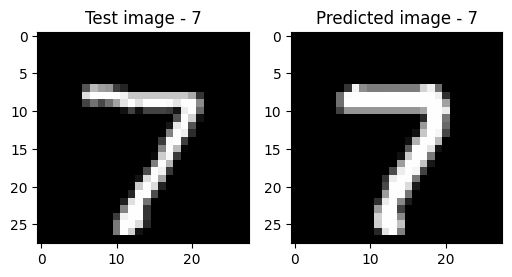

In [4]:
plain_image_index = 0

distances = np.linalg.norm(images - test_images[plain_image_index], axis=1)
n = np.argmin(distances)

f, axes = plt.subplots(1, 2)
axes[0].imshow(test_images_2d[plain_image_index], cmap="gray")
axes[0].set_title(f"Test image - {test_labels[plain_image_index]}")
axes[1].imshow(images_2d[n], cmap="gray")
axes[1].set_title(f"Predicted image - {labels[n]}");

In [45]:
%%timeit

correct_count = 0
predict_images_count = 100

for i in range(predict_images_count):
    distances = np.linalg.norm(images - test_images[i], axis=1)
    n = np.argmin(distances)
    if labels[n] == test_labels[i]:
        correct_count += 1
    print(f"Processing image {i}/{predict_images_count }", end="\r")

print(f"Correct predictions: {correct_count} out of {predict_images_count }")
print(f"Accuracy: {correct_count / predict_images_count  * 100:.2f}%")

Correct predictions: 64 out of 100
Accuracy: 64.00%
Correct predictions: 64 out of 100
Accuracy: 64.00%
Correct predictions: 64 out of 100
Accuracy: 64.00%
Correct predictions: 64 out of 100
Accuracy: 64.00%
Correct predictions: 64 out of 100
Accuracy: 64.00%
Correct predictions: 64 out of 100
Accuracy: 64.00%
Correct predictions: 64 out of 100
Accuracy: 64.00%
Correct predictions: 64 out of 100
Accuracy: 64.00%
18.6 s ± 533 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### PCA

In [26]:
pca_mnist_avg = np.average(images, axis=0)
pca_images_shifted = images - pca_mnist_avg

In [27]:
U, S, Vt = la.svd(pca_images_shifted, full_matrices=False)
V = Vt.T

In [42]:
reduced_dimensions = 50
reduced_V = V[:, :reduced_dimensions]

pca_images_projected = pca_images_shifted @ reduced_V
pca_test_images_projected = (test_images - pca_mnist_avg) @ reduced_V

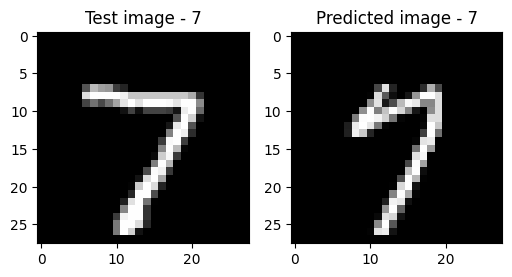

In [30]:
image_index = 0

distances = np.linalg.norm(
    pca_images_projected - pca_test_images_projected[image_index], axis=1
)
n = np.argmin(distances)

f, axes = plt.subplots(1, 2)
axes[0].imshow(test_images_2d[image_index], cmap="gray")
axes[0].set_title(f"Test image - {test_labels[image_index]}")
axes[1].imshow(images_2d[n], cmap="gray")
axes[1].set_title(f"Predicted image - {labels[n]}");

In [44]:
%%timeit

correct_count = 0
pca_predict_images_count = 100

for i in range(pca_predict_images_count):
    pca_test_projection = (test_images[i] - pca_mnist_avg) @ reduced_V
    
    distances = np.linalg.norm(pca_images_projected - pca_test_projection, axis=1)
    n = np.argmin(distances)

    if labels[n] == test_labels[i]:
        correct_count += 1
    print(f"Processing PCA image {i}/{pca_predict_images_count }", end="\r")

print(f"Correct PCA predictions: {correct_count} out of {pca_predict_images_count }")
print(f"PCA accuracy: {correct_count / pca_predict_images_count  * 100:.2f}%")

Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
Correct PCA predictions: 99 out of 100
PCA accuracy: 99.00%
1.27 s ± 16.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### DCT

Discrete cosine transform (DCT), which converts data into a linear combination of cosine waves.  When constructing the DCT matrix ${\bf D}$, the $i$'th entry (row) of the $k$'th basis vector (column) is thus given by: $$ D_{i, k} = \cos\left(\frac{\pi}{N} \left(i + \frac{1}{2}\right)k\right) $$
We also need to make sure each one is a basis vector at the end.

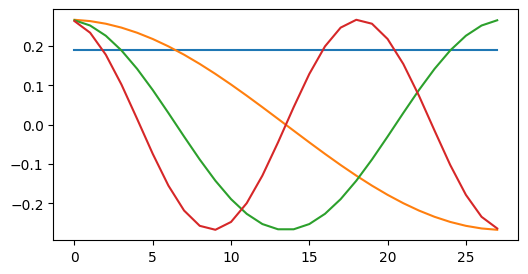

In [47]:
# Since DCT is usual used for 2d images it's prob better to keep it in 2D
DCT_basis = np.zeros((28, 28))

for i in range(28):
    for k in range(28):
        DCT_basis[i, k] = np.cos(np.pi / 28 * (i + 0.5) * k)

for k in range(28):
    norm = la.norm(DCT_basis[:, k])
    DCT_basis[:, k] = DCT_basis[:, k] / norm

plt.plot(DCT_basis[:, :4]);

In [48]:
def compress_image_to_dct(image):
    dct_image = DCT_basis.T @ image @ DCT_basis

    # Base compression on the DCT coefficients of the maxium values
    # .1 of the maximum value
    max_val = np.max(np.abs(dct_image))
    tol = max_val * 0.1

    for i in range(dct_image.shape[0]):
        for j in range(dct_image.shape[1]):
            if np.abs(dct_image[i, j]) < tol:
                dct_image[i, j] = 0

    compressed_chunk = DCT_basis @ dct_image @ DCT_basis.T

    return np.clip(compressed_chunk, 0, 255)

In [49]:
dct_images_2d = images_2d.copy()
for i in range(dct_images_2d.shape[0]):
    image = dct_images_2d[i]
    dct_images_2d[i] = compress_image_to_dct(image)
    print(f"Processed image {i + 1}/{dct_images_2d.shape[0]}", end="\r")

In [50]:
dct_test_images_2d = test_images_2d.copy()
for i in range(dct_test_images_2d.shape[0]):
    image = dct_test_images_2d[i]
    dct_test_images_2d[i] = compress_image_to_dct(image)
    print(f"Processed image {i + 1}/{dct_test_images_2d.shape[0]}", end="\r")

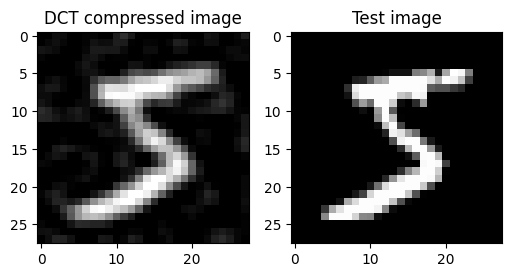

In [59]:
# Just to show how the DCT compression looks like
dct_image_index = 0
f, axes = plt.subplots(1, 2)
axes[0].imshow(dct_images_2d[dct_image_index], cmap="gray")
axes[0].set_title("DCT compressed image")
axes[1].imshow(images_2d[dct_image_index], cmap="gray")
axes[1].set_title("Test image");

In [52]:
dct_images = dct_images_2d.reshape(dct_images_2d.shape[0], -1)
dct_test_images = dct_test_images_2d.reshape(dct_test_images_2d.shape[0], -1)

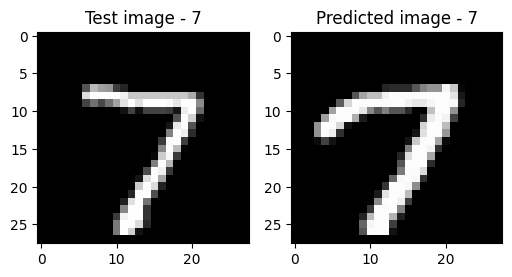

In [53]:
dct_image_index = 0

distances = np.linalg.norm(dct_images - dct_test_images[dct_image_index], axis=1)
n = np.argmin(distances)

f, axes = plt.subplots(1, 2)
axes[0].imshow(test_images_2d[dct_image_index], cmap="gray")
axes[0].set_title(f"Test image - {test_labels[dct_image_index]}")
axes[1].imshow(images_2d[n], cmap="gray")
axes[1].set_title(f"Predicted image - {labels[n]}");

In [55]:
%%timeit

correct_count = 0
dct_predict_images_count = 100

for i in range(dct_predict_images_count):
    distances = np.linalg.norm(dct_images - dct_test_images[i], axis=1)
    n = np.argmin(distances)

    if labels[n] == test_labels[i]:
        correct_count += 1
    print(f"Processing DCT image {i}/{dct_predict_images_count }", end="\r")

print(f"Correct DCT predictions: {correct_count} out of {dct_predict_images_count }")
print(f"DCT accuracy: {correct_count / dct_predict_images_count  * 100:.2f}%")

Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
Correct DCT predictions: 49 out of 100
DCT accuracy: 49.00%
20.5 s ± 779 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## DCT with PCA

We'll hopefully get new eigenvectors that represent how your image varies most in the frequency domain.

In [21]:
dct_mnist_avg = np.average(images, axis=0)
dct_images_shifted = dct_images - dct_mnist_avg

In [22]:
U_dct, S_dct, Vt_dct = la.svd(dct_images_shifted, full_matrices=False)
V_dct = Vt_dct.T

In [61]:
reduced_dimensions = 50
reduced_V_dct = V_dct[:, :reduced_dimensions]

dct_images_projected = dct_images_shifted @ reduced_V_dct
dct_test_images_projected = (dct_test_images - dct_mnist_avg) @ reduced_V_dct

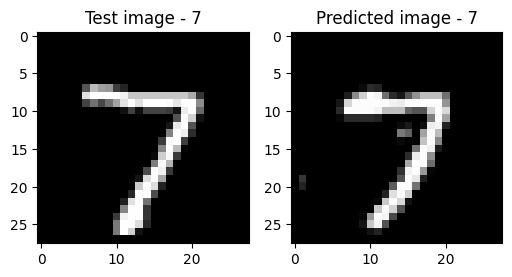

In [34]:
image_index = 0

distances = np.linalg.norm(
    dct_images_projected - dct_test_images_projected[image_index], axis=1
)
n = np.argmin(distances)

f, axes = plt.subplots(1, 2)
axes[0].imshow(test_images_2d[image_index], cmap="gray")
axes[0].set_title(f"Test image - {test_labels[image_index]}")
axes[1].imshow(images_2d[n], cmap="gray")
axes[1].set_title(f"Predicted image - {labels[n]}");

In [62]:
%%timeit

correct_count = 0
dct_pca_predict_images_count = 100

for i in range(dct_pca_predict_images_count):
    dct_test_projection = (test_images[i] - dct_mnist_avg) @ reduced_V_dct
    
    distances = np.linalg.norm(dct_images_projected - dct_test_projection, axis=1)
    n = np.argmin(distances)

    if labels[n] == test_labels[i]:
        correct_count += 1
    print(f"Processing DCT PCA image {i}/{dct_pca_predict_images_count }", end="\r")

print(f"Correct DCT PCA predictions: {correct_count} out of {dct_pca_predict_images_count }")
print(f"DCT PCA accuracy: {correct_count / dct_pca_predict_images_count  * 100:.2f}%")

Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
Correct DCT PCA predictions: 98 out of 100
DCT PCA accuracy: 98.00%
1.48 s ± 113 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Conclusion

18.6 s ± 533 ms, 64% for Plain

1.27 s ± 16.8 ms, 99% for SVD for 50 Dim

20.5 s ± 779 ms, 49% for DCT

1.48 s ± 113 ms, 98% for SVD with DCT for 50 Dim

Basically we end up with SVD and DCT with SVD.
But SVD still manages to win :(

In [63]:
reduced_dimensions = 5

In [64]:
reduced_V = V[:, :reduced_dimensions]

pca_images_projected = pca_images_shifted @ reduced_V
pca_test_images_projected = (test_images - pca_mnist_avg) @ reduced_V

In [65]:
%%timeit

correct_count = 0
pca_predict_images_count = 100

for i in range(pca_predict_images_count):
    pca_test_projection = (test_images[i] - pca_mnist_avg) @ reduced_V

    distances = np.linalg.norm(pca_images_projected - pca_test_projection, axis=1)
    n = np.argmin(distances)

    if labels[n] == test_labels[i]:
        correct_count += 1
    print(f"Processing PCA image {i}/{pca_predict_images_count }", end="\r")

print(f"Correct PCA predictions: {correct_count} out of {pca_predict_images_count }")
print(f"PCA accuracy: {correct_count / pca_predict_images_count  * 100:.2f}%")

Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
PCA accuracy: 64.00%
Correct PCA predictions: 64 out of 100
P

In [66]:
reduced_V_dct = V_dct[:, :reduced_dimensions]

dct_images_projected = dct_images_shifted @ reduced_V_dct
dct_test_images_projected = (dct_test_images - dct_mnist_avg) @ reduced_V_dct

In [67]:
%%timeit

correct_count = 0
dct_pca_predict_images_count = 100

for i in range(dct_pca_predict_images_count):
    dct_test_projection = (test_images[i] - dct_mnist_avg) @ reduced_V_dct
    
    distances = np.linalg.norm(dct_images_projected - dct_test_projection, axis=1)
    n = np.argmin(distances)

    if labels[n] == test_labels[i]:
        correct_count += 1
    print(f"Processing DCT PCA image {i}/{dct_pca_predict_images_count }", end="\r")

print(f"Correct DCT PCA predictions: {correct_count} out of {dct_pca_predict_images_count }")
print(f"DCT PCA accuracy: {correct_count / dct_pca_predict_images_count  * 100:.2f}%")

Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT PCA accuracy: 70.00%
Correct DCT PCA predictions: 70 out of 100
DCT P

135 ms ± 3.4 ms, 64% for SVD for 50 Dim

139 ms ± 5.11 ms per loop, 70% for SVD with DCT for 50 Dim